# Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Import Data

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/farhanage/dataset-for-study/main/heart_failure_clinical_records_dataset.csv')

df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


# PREPROCESSING DATA

In [ ]:
#mengecek tipe data
print(df.dtypes)

age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object


In [ ]:
#melihat ukuran dataset
print(df.shape)

(299, 13)


In [ ]:
#mengecek missing value
missing_values = df.isna().sum()
print(missing_values)

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [ ]:
# Mengecek jumlah baris duplikat
duplicates = df.duplicated()
print("Jumlah baris yang terduplikat adalah: ",duplicates.sum())

# Menampilkan baris yang duplikat
duplicate_rows = df[df.duplicated()]
print(duplicate_rows)

Jumlah baris yang terduplikat adalah:  0
Empty DataFrame
Columns: [age, anaemia, creatinine_phosphokinase, diabetes, ejection_fraction, high_blood_pressure, platelets, serum_creatinine, serum_sodium, sex, smoking, time, DEATH_EVENT]
Index: []


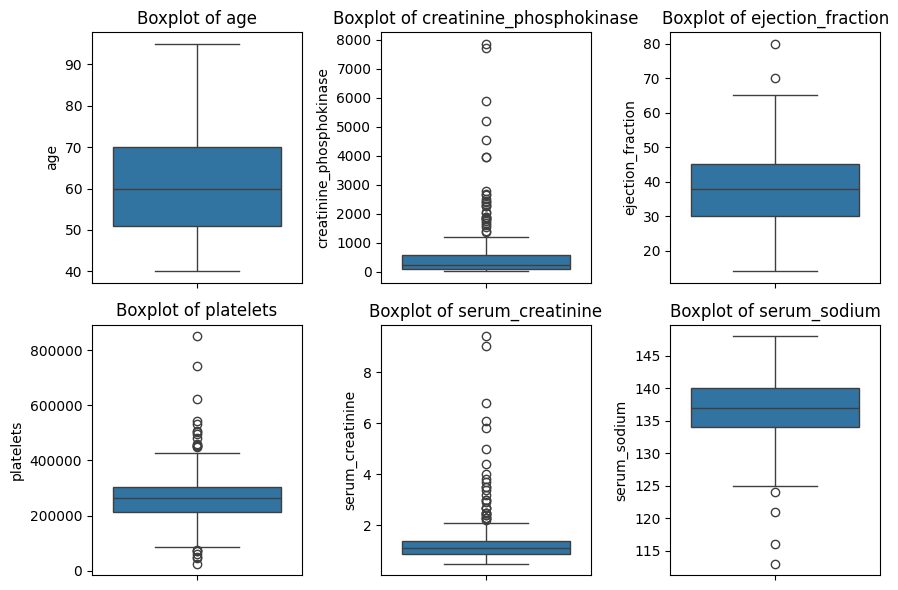

In [ ]:
#mengecek outlier
non_categoric = ['age','creatinine_phosphokinase','ejection_fraction','platelets','serum_creatinine','serum_sodium']

numeric_cols = df[non_categoric]

n = len(non_categoric)
ncols = 3
nrows = n // ncols if n % ncols == 0 else n // ncols + 1

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*3, nrows*3))

for ax, column in zip(axs.flatten(), non_categoric):
    sns.boxplot(y=df[column], ax=ax)
    ax.set_title(f'Boxplot of {column}')

plt.tight_layout()
plt.show()

# PENGELOMPOKKAN VARIABEL NUMERIK

In [ ]:
#fungsi memanggil plot elbow dan plot skor silhouette
def elbow(col):
    Sum_of_squared_distances = []
    K = range(1,10)

    for num_clusters in K :
        kmeans = KMeans(n_clusters=num_clusters)
        kmeans.fit(df[[col]])
        Sum_of_squared_distances.append(kmeans.inertia_)

    plt.plot(K,Sum_of_squared_distances,"bx-")
    plt.xlabel("Values of K")
    plt.ylabel("Sum of squared distances/Inertia")
    plt.title("Elbow Method For Optimal k")
    plt.show()

def silhouette(col):
    range_n_clusters = [i for i in range(2,25)]
    silhouette_avg = []

    for num_clusters in range_n_clusters:
        # initialise kmeans
        kmeans = KMeans(n_clusters=num_clusters)
        kmeans.fit(df[[col]])
        cluster_labels = kmeans.labels_
        # silhouette score
        silhouette_avg.append(silhouette_score(df[[col]], cluster_labels))

    plt.plot(range_n_clusters,silhouette_avg,'bx-')
    plt.xlabel('Values of K')
    plt.ylabel('Silhouette score')
    plt.title('Silhouette analysis For Optimal k')
    plt.show()

def kmeans(col, n_clust):
    kmeans = KMeans(n_clusters=n_clust, random_state=42)
    df[(col+'_lab')] = kmeans.fit_predict(df[[col]])

    ax = plt.subplot(10, 1, 1)
    ax.spines['right'].set_color('none')
    ax.spines['left'].set_color('none')
    ax.yaxis.set_major_locator(ticker.NullLocator())
    ax.spines['top'].set_color('none')
    ax.xaxis.set_ticks_position('bottom')
    ax.tick_params(which='major', width=1.00)
    ax.tick_params(which='major', length=5)
    ax.tick_params(which='minor', width=0.75)
    ax.tick_params(which='minor', length=2.5)
    ax.set_xlim(min(df[col]), max(df[col]))
    ax.set_ylim(0, 1)
    ax.patch.set_alpha(0.0)
    ax.text(0.0, 1, ("Pengelompokan kolom " +col), fontsize=10,
            transform=ax.transAxes)
    plt.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=1.05)

    plt.scatter(x=df[col], y=np.zeros(len(df)), s=20, c=df[(col+"_lab")])
    plt.show()

def hist(col):
    sns.histplot(hue=(col+'_lab'), x=col, data=df)

## Creatinine Phosphokinase

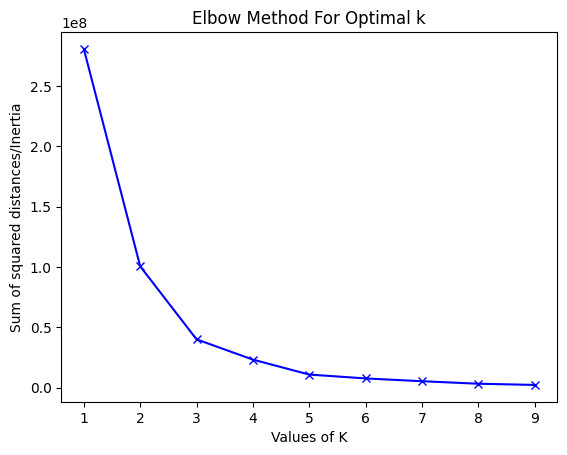

In [ ]:
elbow('creatinine_phosphokinase')

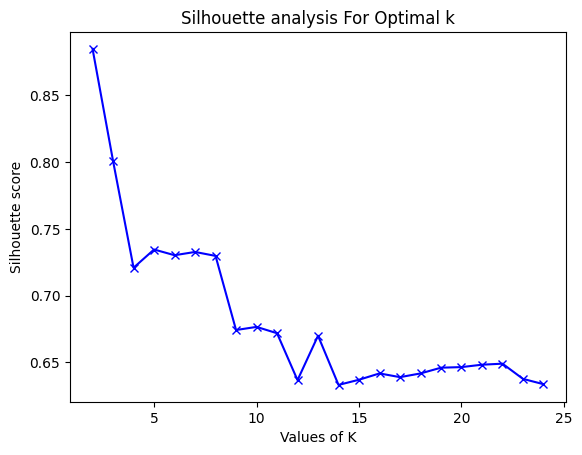

In [ ]:
silhouette('creatinine_phosphokinase')

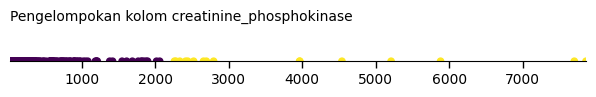

In [ ]:
kmeans('creatinine_phosphokinase', 2)

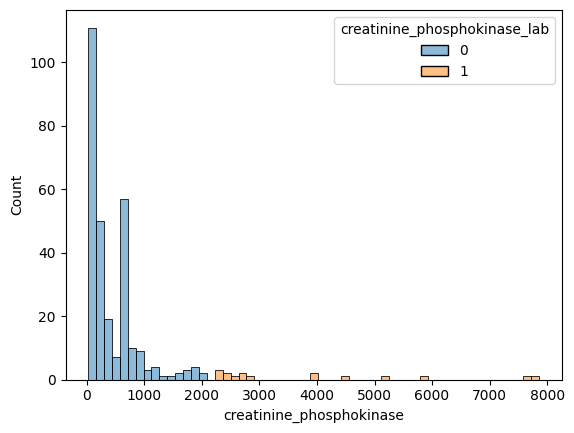

In [ ]:
hist('creatinine_phosphokinase')

## Ejection Fraction

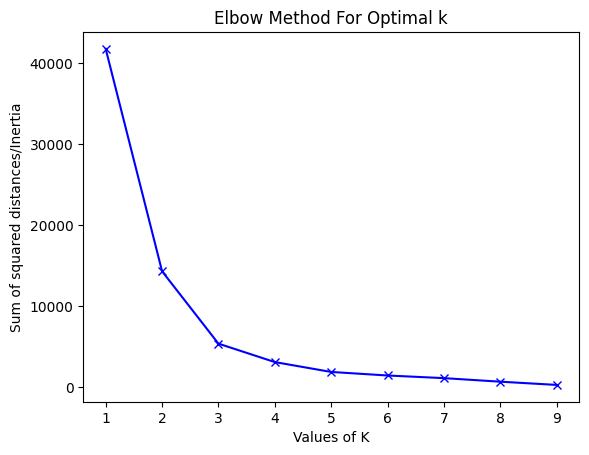

In [ ]:
elbow('ejection_fraction')

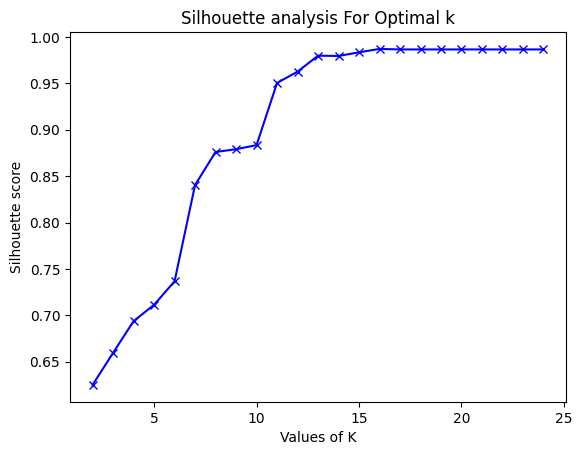

In [ ]:
silhouette('ejection_fraction')

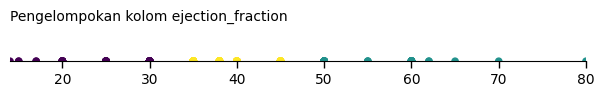

In [ ]:
kmeans('ejection_fraction', 3)

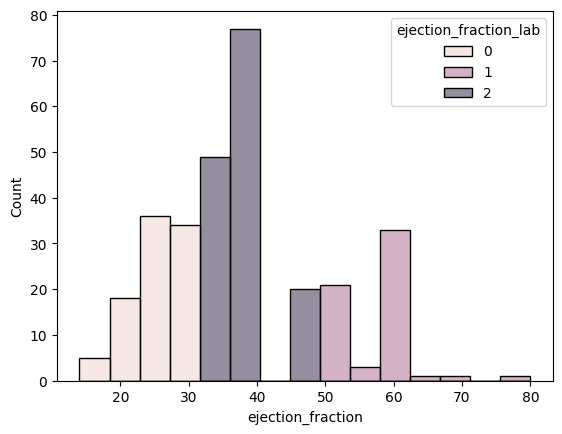

In [ ]:
hist('ejection_fraction')

## Platelets

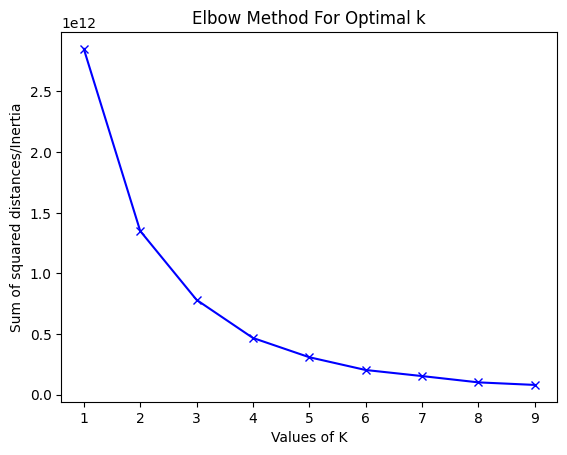

In [ ]:
elbow('platelets')

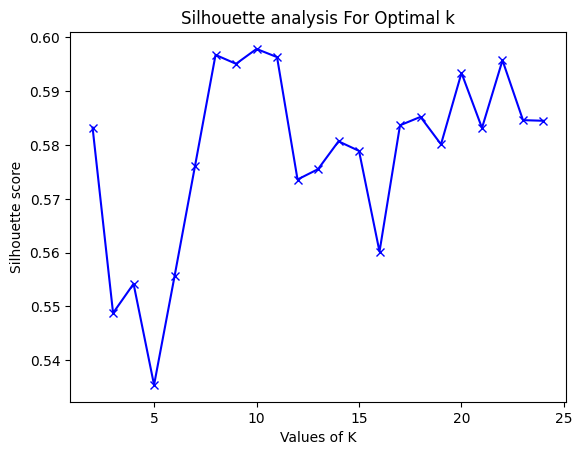

In [ ]:
silhouette('platelets')

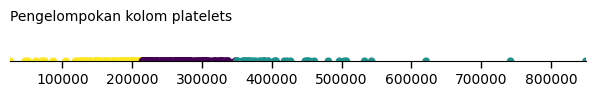

In [ ]:
kmeans('platelets', 3)

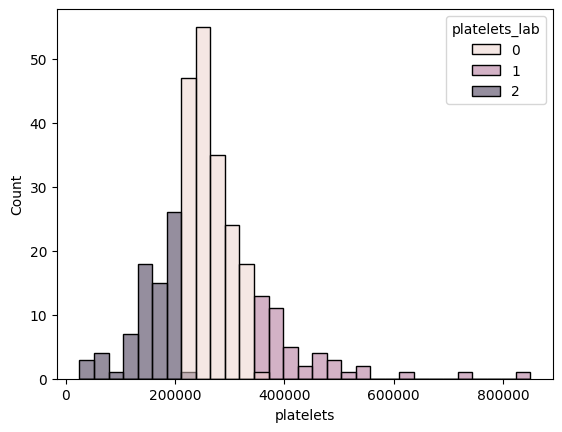

In [ ]:
hist('platelets')

## Serum Creatinine

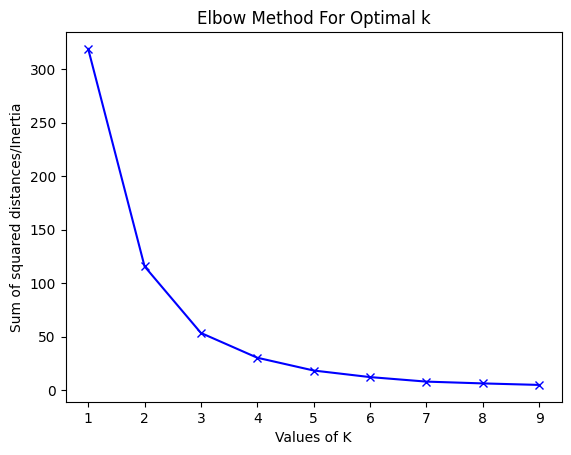

In [ ]:
elbow('serum_creatinine')

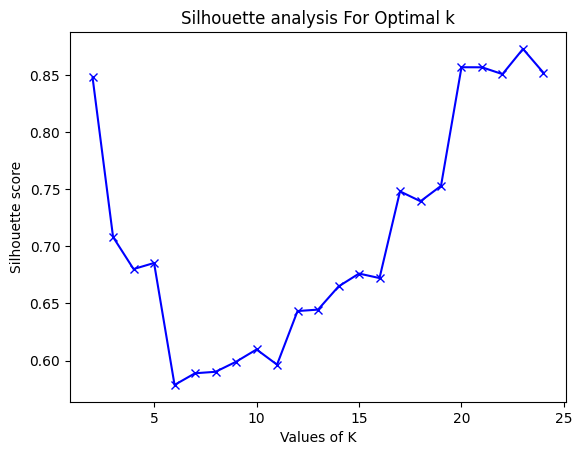

In [ ]:
silhouette('serum_creatinine')

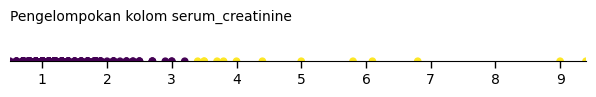

In [ ]:
kmeans('serum_creatinine', 2)

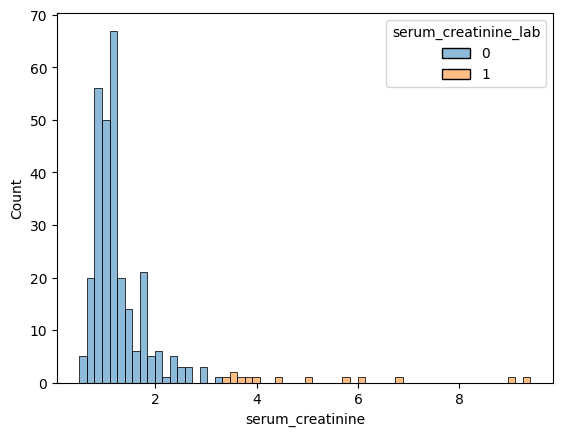

In [ ]:
hist('serum_creatinine')

## Serum Sodium

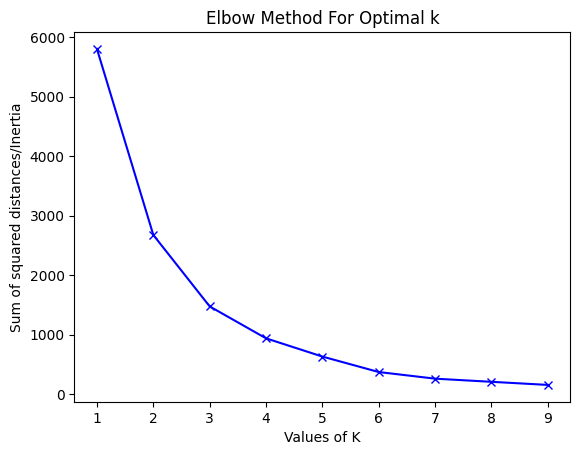

In [ ]:
elbow('serum_sodium')

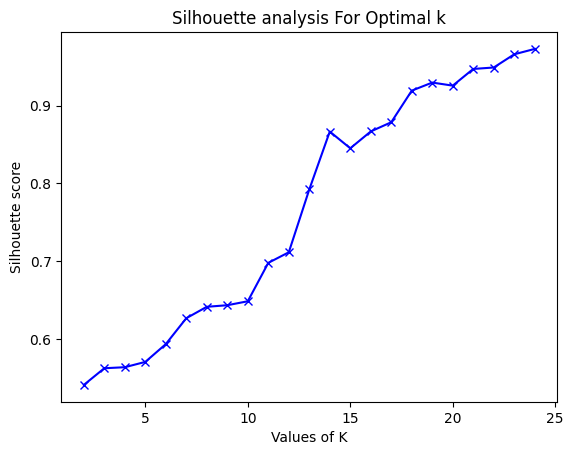

In [ ]:
silhouette('serum_sodium')

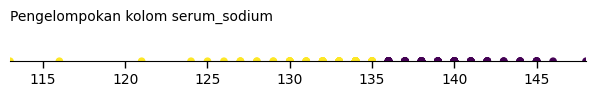

In [ ]:
kmeans('serum_sodium', 2)

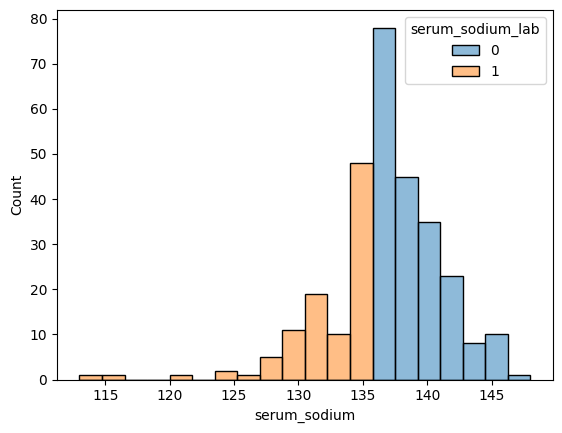

In [ ]:
hist('serum_sodium')

## MEMBUAT DATASET BARU

In [ ]:
columns = ['creatinine_phosphokinase','ejection_fraction','platelets','serum_creatinine','serum_sodium']
for col in columns:
    df[col] = df[(col+'_lab')]

df.iloc[:,0:13]

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,0,0,0,1,0,0,1,1,0,4,1
1,55.0,0,1,0,2,0,0,0,0,1,0,6,1
2,65.0,0,0,0,0,0,2,0,1,1,1,7,1
3,50.0,1,0,0,0,0,2,0,0,1,0,7,1
4,65.0,1,0,1,0,0,0,0,1,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,0,1,2,1,2,0,0,1,1,270,0
295,55.0,0,0,0,2,0,0,0,0,0,0,271,0
296,45.0,0,0,1,1,0,1,0,0,0,0,278,0
297,45.0,0,1,0,2,0,2,0,0,1,1,280,0


In [ ]:
#melihat jumlah nilai unik pada setiap variabel
for col in df.columns:
    print(f'Total unique value untuk kolom {col} : {len(df[col].unique())}')

Total unique value untuk kolom age : 47
Total unique value untuk kolom anaemia : 2
Total unique value untuk kolom creatinine_phosphokinase : 2
Total unique value untuk kolom diabetes : 2
Total unique value untuk kolom ejection_fraction : 3
Total unique value untuk kolom high_blood_pressure : 2
Total unique value untuk kolom platelets : 3
Total unique value untuk kolom serum_creatinine : 2
Total unique value untuk kolom serum_sodium : 2
Total unique value untuk kolom sex : 2
Total unique value untuk kolom smoking : 2
Total unique value untuk kolom time : 148
Total unique value untuk kolom DEATH_EVENT : 2
Total unique value untuk kolom creatinine_phosphokinase_lab : 2
Total unique value untuk kolom ejection_fraction_lab : 3
Total unique value untuk kolom platelets_lab : 3
Total unique value untuk kolom serum_creatinine_lab : 2
Total unique value untuk kolom serum_sodium_lab : 2


In [ ]:
df.iloc[:,0:13].to_csv('processed_heart.csv', index=False)